In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")

wot_dir = project_dir / "results/wot_lanner_full/wot_inputs/full_all_cells_all_ref_celltype"

tmaps_prefix = wot_dir / "tmaps.full_all_cells_all_ref_celltype"
cell_sets_path = wot_dir / "cell_sets/cell_sets.full_all_cells.ref_celltype.gmt"

print("WOT dir:", wot_dir)
print("tmaps prefix:", tmaps_prefix)
print("cell sets:", cell_sets_path)

print("\nWOT dir exists:", wot_dir.exists())
print("cell sets exists:", cell_sets_path.exists())

print("\nFiles matching tmaps prefix:")
for x in sorted(wot_dir.glob("tmaps.full_all_cells_all_ref_celltype*")):
    print(x.name)

WOT dir: /mnt/yiming/nfs_share/projects/hypoblast/results/wot_lanner_full/wot_inputs/full_all_cells_all_ref_celltype
tmaps prefix: /mnt/yiming/nfs_share/projects/hypoblast/results/wot_lanner_full/wot_inputs/full_all_cells_all_ref_celltype/tmaps.full_all_cells_all_ref_celltype
cell sets: /mnt/yiming/nfs_share/projects/hypoblast/results/wot_lanner_full/wot_inputs/full_all_cells_all_ref_celltype/cell_sets/cell_sets.full_all_cells.ref_celltype.gmt

WOT dir exists: True
cell sets exists: True

Files matching tmaps prefix:
tmaps.full_all_cells_all_ref_celltype_0.0_1.0.h5ad
tmaps.full_all_cells_all_ref_celltype_1.0_2.0.h5ad
tmaps.full_all_cells_all_ref_celltype_10.0_12.0.h5ad
tmaps.full_all_cells_all_ref_celltype_12.0_14.0.h5ad
tmaps.full_all_cells_all_ref_celltype_14.0_19.0.h5ad
tmaps.full_all_cells_all_ref_celltype_2.0_3.0.h5ad
tmaps.full_all_cells_all_ref_celltype_3.0_4.0.h5ad
tmaps.full_all_cells_all_ref_celltype_4.0_5.0.h5ad
tmaps.full_all_cells_all_ref_celltype_5.0_6.0.h5ad
tmaps.full_a

In [2]:
from pathlib import Path
import re
import scanpy as sc
import pandas as pd

def read_wot_tmaps_manual(wot_dir, prefix="tmaps.full_all_cells_all_ref_celltype"):
    """
    Manually read WOT transport maps saved as:
    {prefix}_{t1}_{t2}.h5ad
    
    Returns a list of dicts:
    [
        {"transport_map": AnnData, "t1": float, "t2": float, "path": Path},
        ...
    ]
    """
    wot_dir = Path(wot_dir)
    
    pattern = re.compile(
        rf"^{re.escape(prefix)}_(\d+(?:\.\d+)?)_(\d+(?:\.\d+)?)\.h5ad$"
    )
    
    tmaps = []
    
    for path in sorted(wot_dir.glob(f"{prefix}_*.h5ad")):
        m = pattern.match(path.name)
        if m is None:
            print(f"Skip unmatched file: {path.name}")
            continue
        
        t1 = float(m.group(1))
        t2 = float(m.group(2))
        
        tmap = sc.read_h5ad(path)
        
        tmaps.append({
            "transport_map": tmap,
            "t1": t1,
            "t2": t2,
            "path": path,
        })
    
    tmaps = sorted(tmaps, key=lambda x: x["t1"])
    
    if len(tmaps) == 0:
        raise ValueError(f"No transport maps loaded from {wot_dir}")
    
    return tmaps

In [3]:
tmaps = read_wot_tmaps_manual(
    wot_dir=wot_dir,
    prefix="tmaps.full_all_cells_all_ref_celltype",
)

print("Number of tmaps:", len(tmaps))

for x in tmaps:
    print(
        x["t1"],
        "->",
        x["t2"],
        x["transport_map"].shape,
        x["path"].name,
    )

Number of tmaps: 13
0.0 -> 1.0 (2, 6) tmaps.full_all_cells_all_ref_celltype_0.0_1.0.h5ad
1.0 -> 2.0 (6, 12) tmaps.full_all_cells_all_ref_celltype_1.0_2.0.h5ad
2.0 -> 3.0 (12, 84) tmaps.full_all_cells_all_ref_celltype_2.0_3.0.h5ad
3.0 -> 4.0 (84, 190) tmaps.full_all_cells_all_ref_celltype_3.0_4.0.h5ad
4.0 -> 5.0 (190, 335) tmaps.full_all_cells_all_ref_celltype_4.0_5.0.h5ad
5.0 -> 6.0 (335, 548) tmaps.full_all_cells_all_ref_celltype_5.0_6.0.h5ad
6.0 -> 7.0 (548, 543) tmaps.full_all_cells_all_ref_celltype_6.0_7.0.h5ad
7.0 -> 8.0 (543, 58) tmaps.full_all_cells_all_ref_celltype_7.0_8.0.h5ad
8.0 -> 9.0 (58, 68) tmaps.full_all_cells_all_ref_celltype_8.0_9.0.h5ad
9.0 -> 10.0 (68, 75) tmaps.full_all_cells_all_ref_celltype_9.0_10.0.h5ad
10.0 -> 12.0 (75, 85) tmaps.full_all_cells_all_ref_celltype_10.0_12.0.h5ad
12.0 -> 14.0 (85, 128) tmaps.full_all_cells_all_ref_celltype_12.0_14.0.h5ad
14.0 -> 19.0 (128, 1170) tmaps.full_all_cells_all_ref_celltype_14.0_19.0.h5ad


In [4]:
def read_gmt_as_dict(gmt_path):
    cell_sets_dict = {}

    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 3:
                set_name = parts[0]
                cells = parts[2:]
                cell_sets_dict[set_name] = cells

    return cell_sets_dict


cell_sets_dict = read_gmt_as_dict(cell_sets_path)

print("Number of cell sets:", len(cell_sets_dict))
print(pd.Series({k: len(v) for k, v in cell_sets_dict.items()}).sort_values(ascending=False))

Number of cell sets: 32
TE                             982
Mesoderm                       278
Late_EPI                       202
Morula                         202
Early_EPI                      189
PriS                           167
ExE_Mes                        151
Prelineage                     129
CTB                            121
STB                            112
AdvMes                         106
8 cell                          84
Early_Hypoblast                 77
DE                              53
YSE                             52
ICM                             51
Late_Hypoblast                  43
EVT                             41
Hemogenic_Endothelium           36
Erythroblasts                   32
Blood_Progenitors               29
Erythro-Myeloid_Progenitors     28
Late_Amnion                     28
Axial Mes                       22
Amnion.Ecto                     20
2-4 cell                        18
Myeloid_Progenitors             17
EPI.PrE.INT                    

In [5]:
from scipy import sparse
import numpy as np
import pandas as pd


def get_tmap_by_edge(tmaps):
    """
    Create dict: (t1, t2) -> transport AnnData
    """
    return {
        (float(x["t1"]), float(x["t2"])): x["transport_map"]
        for x in tmaps
    }


def propagate_cells_to_time(
    tmaps,
    source_cells,
    start_time,
    end_time,
    normalize_source=True,
):
    """
    Propagate a source cell set from start_time to end_time using sequential WOT tmaps.

    Returns
    -------
    fate_series:
        pd.Series indexed by final cells at end_time, values = probability mass.
    """

    tmap_dict = get_tmap_by_edge(tmaps)

    # Find ordered path from start_time to end_time
    edges = sorted(tmap_dict.keys(), key=lambda x: x[0])
    path_edges = [
        edge for edge in edges
        if edge[0] >= float(start_time) and edge[1] <= float(end_time)
    ]

    # More strict: chain must begin at start_time and end at end_time
    chain = []
    current = float(start_time)

    while current < float(end_time):
        candidates = [e for e in edges if e[0] == current]
        if len(candidates) == 0:
            raise ValueError(f"No transport map starting from time {current}")

        # choose the next available edge
        next_edge = candidates[0]
        chain.append(next_edge)
        current = next_edge[1]

        if current > float(end_time):
            raise ValueError(f"Transport chain overshot end_time: {current} > {end_time}")

    if current != float(end_time):
        raise ValueError(f"Could not build chain from {start_time} to {end_time}")

    print("Transport chain:")
    print(chain)

    # Initialize source vector over cells at start_time
    first_tmap = tmap_dict[chain[0]]
    start_cells = first_tmap.obs_names

    source_cells = [c for c in source_cells if c in set(start_cells)]

    if len(source_cells) == 0:
        raise ValueError("No source cells matched first transport map obs_names")

    source_idx = start_cells.get_indexer(source_cells)

    p = np.zeros(first_tmap.n_obs, dtype=float)
    p[source_idx] = 1.0

    if normalize_source:
        p = p / p.sum()

    # Propagate through chain
    current_cells = start_cells

    for edge in chain:
        tmap = tmap_dict[edge]

        # make sure current vector aligns with tmap.obs_names
        if not np.array_equal(np.array(current_cells), np.array(tmap.obs_names)):
            p_aligned = pd.Series(p, index=current_cells).reindex(tmap.obs_names).fillna(0).values
        else:
            p_aligned = p

        X = tmap.X

        if sparse.issparse(X):
            p = p_aligned @ X
            p = np.asarray(p).ravel()
        else:
            p = p_aligned @ np.asarray(X)

        current_cells = tmap.var_names

    fate_series = pd.Series(p, index=current_cells, name=f"{start_time}_to_{end_time}")

    return fate_series

In [6]:
def summarize_fate_to_cell_sets(
    fate_series,
    cell_sets_dict,
    target_cellsets=None,
    normalize=True,
):
    """
    Summarize propagated fate probability over target cell sets.

    fate_series:
        pd.Series indexed by final cell IDs.

    cell_sets_dict:
        dict: cell set name -> list of cell IDs.

    target_cellsets:
        If None, use all cell sets.

    normalize:
        If True, normalize summarized probabilities to sum to 1 across selected targets.
    """

    if target_cellsets is None:
        target_cellsets = list(cell_sets_dict.keys())

    fate_cells = set(fate_series.index)

    out = {}

    for target in target_cellsets:
        cells = [c for c in cell_sets_dict[target] if c in fate_cells]

        if len(cells) == 0:
            out[target] = 0.0
        else:
            out[target] = fate_series.loc[cells].sum()

    out = pd.Series(out, dtype=float)

    if normalize and out.sum() > 0:
        out = out / out.sum()

    return out

In [7]:
source_set = "Early_Hypoblast"

In [8]:
source_set = "Early_Hypoblast"
start_time = 5.0
end_time = 19.0

source_cells = cell_sets_dict[source_set]

fate_series = propagate_cells_to_time(
    tmaps=tmaps,
    source_cells=source_cells,
    start_time=start_time,
    end_time=end_time,
    normalize_source=True,
)

fate_series.head(), fate_series.sum()

Transport chain:
[(5.0, 6.0), (6.0, 7.0), (7.0, 8.0), (8.0, 9.0), (9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]


(Lanner_sc7785290    0.000304
 Lanner_sc7786612    0.004508
 Lanner_sc7786605    0.000970
 Lanner_sc7785737    0.000383
 Lanner_sc7785398    0.000844
 Name: 5.0_to_19.0, dtype: float64,
 np.float64(1.5565799582165067))

In [9]:
target_fate = summarize_fate_to_cell_sets(
    fate_series=fate_series,
    cell_sets_dict=cell_sets_dict,
    target_cellsets=None,
    normalize=True,
)

target_fate.sort_values(ascending=False)

YSE                            0.315183
Late_Hypoblast                 0.164760
Mesoderm                       0.147951
DE                             0.143043
AdvMes                         0.069212
ExE_Mes                        0.052077
PriS                           0.029402
Axial Mes                      0.013946
Late_EPI                       0.013525
Hemogenic_Endothelium          0.010097
Late_Amnion                    0.009433
Erythro-Myeloid_Progenitors    0.008489
Blood_Progenitors              0.007609
Erythroblasts                  0.007318
Amnion.Ecto                    0.004409
Myeloid_Progenitors            0.002846
PGC                            0.000702
EPI.PrE.INT                    0.000000
EVT                            0.000000
Early_EPI                      0.000000
Ambiguous                      0.000000
8 cell                         0.000000
2-4 cell                       0.000000
CTB                            0.000000
Early_Hypoblast                0.000000


In [10]:
fate_df = target_fate.to_frame().T
fate_df.index = [f"{source_set}_E{int(start_time)}_to_E{int(end_time)}"]

fate_df

,2-4 cell,8 cell,AdvMes,Ambiguous,Amnion.Ecto,Axial Mes,Blood_Progenitors,CTB,DE,EPI.PrE.INT,...,Morula,Myeloid_Progenitors,PGC,Prelineage,PriS,STB,TE,Unknown,YSE,Zygote
Early_Hypoblast_E5_to_E19,0.0,0.0,0.069212,0.0,0.004409,0.013946,0.007609,0.0,0.143043,0.0,...,0.0,0.002846,0.000702,0.0,0.029402,0.0,0.0,0.0,0.315183,0.0


In [11]:
def build_fate_df_for_source_over_start_times(
    tmaps,
    cell_sets_dict,
    source_set,
    start_times,
    end_time,
    target_cellsets=None,
    normalize_source=True,
    normalize_targets=True,
):
    rows = []

    for start_time in start_times:
        print("\n" + "=" * 80)
        print(f"{source_set}: E{start_time} -> E{end_time}")

        source_cells = cell_sets_dict[source_set]

        fate_series = propagate_cells_to_time(
            tmaps=tmaps,
            source_cells=source_cells,
            start_time=float(start_time),
            end_time=float(end_time),
            normalize_source=normalize_source,
        )

        target_fate = summarize_fate_to_cell_sets(
            fate_series=fate_series,
            cell_sets_dict=cell_sets_dict,
            target_cellsets=target_cellsets,
            normalize=normalize_targets,
        )

        target_fate.name = f"{source_set}_E{int(start_time)}_to_E{int(end_time)}"
        rows.append(target_fate)

    fate_df = pd.DataFrame(rows)

    return fate_df

In [12]:
fate_df = build_fate_df_for_source_over_start_times(
    tmaps=tmaps,
    cell_sets_dict=cell_sets_dict,
    source_set="Early_Hypoblast",
    start_times=[5, 6, 7, 8, 9, 10],
    end_time=19,
    target_cellsets=None,
    normalize_source=True,
    normalize_targets=True,
)

fate_df


Early_Hypoblast: E5 -> E19
Transport chain:
[(5.0, 6.0), (6.0, 7.0), (7.0, 8.0), (8.0, 9.0), (9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]

Early_Hypoblast: E6 -> E19
Transport chain:
[(6.0, 7.0), (7.0, 8.0), (8.0, 9.0), (9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]

Early_Hypoblast: E7 -> E19
Transport chain:
[(7.0, 8.0), (8.0, 9.0), (9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]

Early_Hypoblast: E8 -> E19
Transport chain:
[(8.0, 9.0), (9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]

Early_Hypoblast: E9 -> E19
Transport chain:
[(9.0, 10.0), (10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]

Early_Hypoblast: E10 -> E19
Transport chain:
[(10.0, 12.0), (12.0, 14.0), (14.0, 19.0)]


,2-4 cell,8 cell,AdvMes,Ambiguous,Amnion.Ecto,Axial Mes,Blood_Progenitors,CTB,DE,EPI.PrE.INT,...,Morula,Myeloid_Progenitors,PGC,Prelineage,PriS,STB,TE,Unknown,YSE,Zygote
Early_Hypoblast_E5_to_E19,0.0,0.0,0.069212,0.0,0.004409,0.013946,0.007609,0.0,0.143043,0.0,...,0.0,0.002846,0.000702,0.0,0.029402,0.0,0.0,0.0,0.315183,0.0
Early_Hypoblast_E6_to_E19,0.0,0.0,0.065050,0.0,0.004772,0.013875,0.011242,0.0,0.125943,0.0,...,0.0,0.005154,0.000890,0.0,0.031295,0.0,0.0,0.0,0.325679,0.0
Early_Hypoblast_E7_to_E19,0.0,0.0,0.066201,0.0,0.005403,0.013550,0.008654,0.0,0.129230,0.0,...,0.0,0.003519,0.001190,0.0,0.038758,0.0,0.0,0.0,0.319071,0.0
Early_Hypoblast_E8_to_E19,0.0,0.0,0.063937,0.0,0.003471,0.012202,0.004830,0.0,0.142680,0.0,...,0.0,0.000838,0.000408,0.0,0.022755,0.0,0.0,0.0,0.366118,0.0
Early_Hypoblast_E9_to_E19,0.0,0.0,0.064011,0.0,0.003475,0.012216,0.004832,0.0,0.142805,0.0,...,0.0,0.000839,0.000408,0.0,0.022781,0.0,0.0,0.0,0.365608,0.0
Early_Hypoblast_E10_to_E19,0.0,0.0,0.041386,0.0,0.002176,0.006066,0.004341,0.0,0.094161,0.0,...,0.0,0.000496,0.000239,0.0,0.013400,0.0,0.0,0.0,0.544888,0.0


In [13]:
table_dir = project_dir / "results/tables/wot_lanner_full"
table_dir.mkdir(parents=True, exist_ok=True)

fate_df.to_csv(
    table_dir / "wot_Early_Hypoblast_E5_E10_to_E19_fate_probability.csv"
)

In [14]:
wot_label_display_map = {
    "Early_Hypoblast": "Early Hypoblast",
    "Late_Hypoblast": "Late Hypoblast",
    "YSE": "YSE",
    "DE": "DE",
    "Mesoderm": "Mesoderm",
    "AdvMes": "Adv Mes",
    "ExE_Mes": "ExE Mes",
    "Axial_Mes": "Axial Mes",
    "Late_EPI": "Late EPI",
    "PriS": "PriS",
    "Amnion_Ecto": "Amnion Ecto",
    "Late_Amnion": "Late Amnion",
    "Hemogenic_Endothelium": "HE",
    "Blood_Progenitors": "Blood Progenitors",
    "Erythro-Myeloid_Progenitors": "EMP",
    "Erythroblasts": "Erythroblasts",
    "Myeloid_Progenitors": "Myeloid Progenitors",
    "PGC": "PGC",
}

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_wot_fate_heatmap_top_targets(
    fate_df,
    top_n=10,
    title=None,
    figsize=(8, 3.5),
    cmap="YlGnBu",
    vmax=None,
    annot=True,
    annot_threshold=0.01,
    label_display_map=None,
    save_path=None,
    dpi=300,
):
    """
    Plot WOT fate probability heatmap with top target columns only.

    Parameters
    ----------
    fate_df:
        rows = source query
        columns = target cell sets
        values = fate probability
    """

    # Select top targets by max probability across rows
    top_targets = (
        fate_df.max(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    plot_df = fate_df.loc[:, top_targets].copy()

    if vmax is None:
        vmax = plot_df.values.max()

    # Build annotation matrix
    if annot:
        annot_df = plot_df.applymap(
            lambda x: f"{x:.2f}" if x >= annot_threshold else ""
        )
    else:
        annot_df = False

    # Display labels
    xlabels = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.columns
    ]

    ylabels = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.index
    ]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        annot=annot_df,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Fate probability"},
    )

    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)

    ax.set_xlabel("Target cell type")
    ax.set_ylabel("Source query")

    if title is not None:
        ax.set_title(title, fontsize=13, pad=10)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return plot_df

/tmp/ipykernel_3467598/3410835629.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = plot_df.applymap(


Saved to /mnt/yiming/nfs_share/projects/hypoblast/results/figures/504_wot_lanner_full_plot/wot_Early_Hypoblast_E5_E10_to_E19_top10_heatmap.pdf


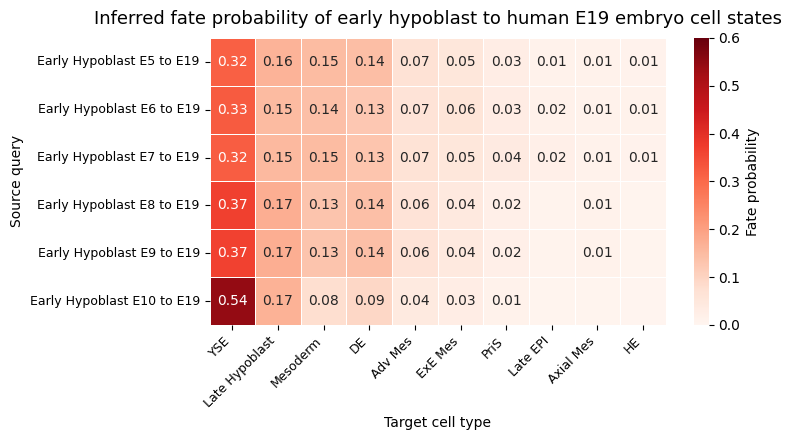

In [26]:
fig_dir = project_dir / "results/figures/504_wot_lanner_full_plot"
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df_top = plot_wot_fate_heatmap_top_targets(
    fate_df=fate_df,
    top_n=10,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(8, 4.5),
    cmap="Reds",
    vmax=0.6,
    annot=True,
    annot_threshold=0.01,
    label_display_map=wot_label_display_map,
    save_path=fig_dir / "wot_Early_Hypoblast_E5_E10_to_E19_top10_heatmap.pdf",
)

In [19]:
target_order = [
    # hypoblast / endoderm
    "YSE",
    "Late_Hypoblast",
    "Early_Hypoblast",
    "DE",

    # mesoderm / ExM
    "Mesoderm",
    "AdvMes",
    "ExE_Mes",
    "Axial_Mes",

    # epithelial / embryonic
    "Late_EPI",
    "PriS",
    "Amnion_Ecto",
    "Late_Amnion",

    # endothelial / blood
    "Hemogenic_Endothelium",
    "Blood_Progenitors",
    "Erythro-Myeloid_Progenitors",
    "Erythroblasts",
    "Myeloid_Progenitors",

    # other
    "PGC",
]

In [20]:
def plot_wot_fate_heatmap_ordered(
    fate_df,
    target_order,
    title=None,
    figsize=(11, 3.8),
    cmap="YlGnBu",
    vmax=None,
    annot=True,
    annot_threshold=0.01,
    label_display_map=None,
    save_path=None,
    dpi=300,
):
    """
    Plot WOT fate probability heatmap with manually ordered target columns.
    """

    ordered_targets = [x for x in target_order if x in fate_df.columns]
    remaining_targets = [x for x in fate_df.columns if x not in ordered_targets]

    plot_df = fate_df.loc[:, ordered_targets + remaining_targets].copy()

    if vmax is None:
        vmax = plot_df.values.max()

    if annot:
        annot_df = plot_df.applymap(
            lambda x: f"{x:.2f}" if x >= annot_threshold else ""
        )
    else:
        annot_df = False

    xlabels = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.columns
    ]

    ylabels = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.index
    ]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        annot=annot_df,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Fate probability"},
    )

    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)

    ax.set_xlabel("Target cell type")
    ax.set_ylabel("Source query")

    if title is not None:
        ax.set_title(title, fontsize=13, pad=10)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return plot_df

/tmp/ipykernel_3467598/1749252130.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = plot_df.applymap(


Saved to /mnt/yiming/nfs_share/projects/hypoblast/results/figures/504_wot_lanner_full_plot/wot_Early_Hypoblast_E5_E10_to_E19_ordered_heatmap.pdf


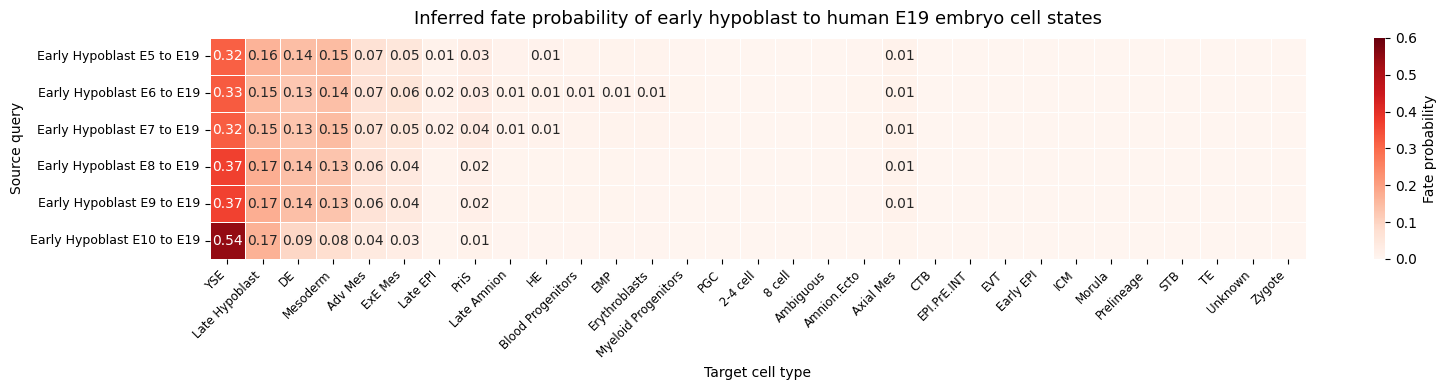

In [28]:
fate_df_plot = fate_df.drop(columns=["Early_Hypoblast"], errors="ignore")

plot_df_ordered = plot_wot_fate_heatmap_ordered(
    fate_df=fate_df_plot,
    target_order=target_order,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(16, 4),
    cmap="Reds",
    vmax=0.6,
    annot=True,
    annot_threshold=0.01,
    label_display_map=wot_label_display_map,
    save_path=fig_dir / "wot_Early_Hypoblast_E5_E10_to_E19_ordered_heatmap.pdf",
)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_wot_top_targets_barplot(
    fate_df,
    top_n=6,
    drop_targets=None,
    label_display_map=None,
    title=None,
    figsize=(7, 4),
    cmap_name="tab10",
    save_path=None,
    dpi=300,
):
    """
    Grouped horizontal barplot:
    rows = source queries
    bars = top target fate probabilities.
    """

    plot_df = fate_df.copy()

    if drop_targets is not None:
        plot_df = plot_df.drop(columns=drop_targets, errors="ignore")

    top_targets = (
        plot_df.max(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    plot_df = plot_df[top_targets]

    # display labels
    display_cols = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.columns
    ]

    display_rows = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in plot_df.index
    ]

    fig, ax = plt.subplots(figsize=figsize)

    y = np.arange(plot_df.shape[0])
    bar_height = 0.8 / len(top_targets)

    cmap = plt.get_cmap(cmap_name)

    for i, target in enumerate(top_targets):
        offset = (i - (len(top_targets) - 1) / 2) * bar_height

        ax.barh(
            y + offset,
            plot_df[target].values,
            height=bar_height,
            label=display_cols[i],
            color=cmap(i),
            alpha=0.9,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(display_rows)
    ax.invert_yaxis()

    ax.set_xlabel("Fate probability")
    ax.set_ylabel("Source query")

    if title is not None:
        ax.set_title(title, pad=12)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        title="Target",
    )

    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return plot_df

Saved to /mnt/yiming/nfs_share/projects/hypoblast/results/figures/504_wot_lanner_full_plot/wot_Early_Hypoblast_E5_E10_to_E19_top6_barplot.pdf


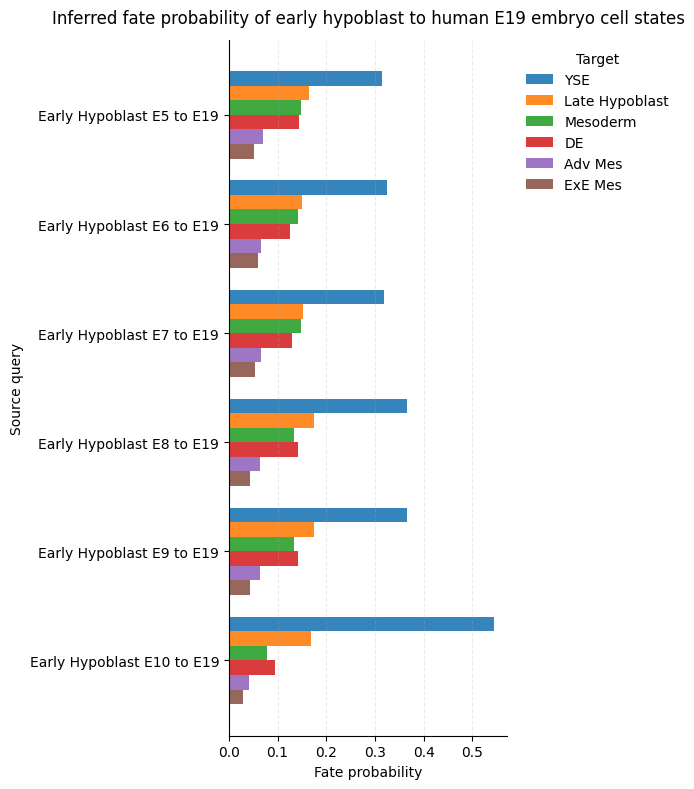

In [31]:
plot_df_bar = plot_wot_top_targets_barplot(
    fate_df=fate_df,
    top_n=6,
    drop_targets=["Early_Hypoblast"],
    label_display_map=wot_label_display_map,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(7, 8),
    save_path=fig_dir / "wot_Early_Hypoblast_E5_E10_to_E19_top6_barplot.pdf",
)

In [32]:
def plot_wot_fate_stacked_barplot(
    fate_df,
    top_n=8,
    drop_targets=None,
    label_display_map=None,
    title=None,
    figsize=(6, 4),
    cmap_name="tab20",
    save_path=None,
    dpi=300,
):
    """
    Stacked barplot:
    x = source queries
    stacked segments = target fate probabilities.
    Top targets are shown; all remaining targets are grouped as Other.
    """

    plot_df = fate_df.copy()

    if drop_targets is not None:
        plot_df = plot_df.drop(columns=drop_targets, errors="ignore")

    top_targets = (
        plot_df.max(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    other_targets = [x for x in plot_df.columns if x not in top_targets]

    stack_df = plot_df[top_targets].copy()

    if len(other_targets) > 0:
        stack_df["Other"] = plot_df[other_targets].sum(axis=1)

    display_cols = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in stack_df.columns
    ]

    display_rows = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in stack_df.index
    ]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(stack_df.shape[0])
    bottom = np.zeros(stack_df.shape[0])

    cmap = plt.get_cmap(cmap_name)

    for i, col in enumerate(stack_df.columns):
        ax.bar(
            x,
            stack_df[col].values,
            bottom=bottom,
            label=display_cols[i],
            color=cmap(i),
            width=0.75,
        )
        bottom += stack_df[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(display_rows, rotation=45, ha="right")

    ax.set_ylabel("Fate probability")
    ax.set_xlabel("Source query")

    if title is not None:
        ax.set_title(title, pad=12)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        title="Target",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return stack_df

Saved to /mnt/yiming/nfs_share/projects/hypoblast/results/figures/504_wot_lanner_full_plot/wot_Early_Hypoblast_E5_E10_to_E19_stacked_barplot.pdf


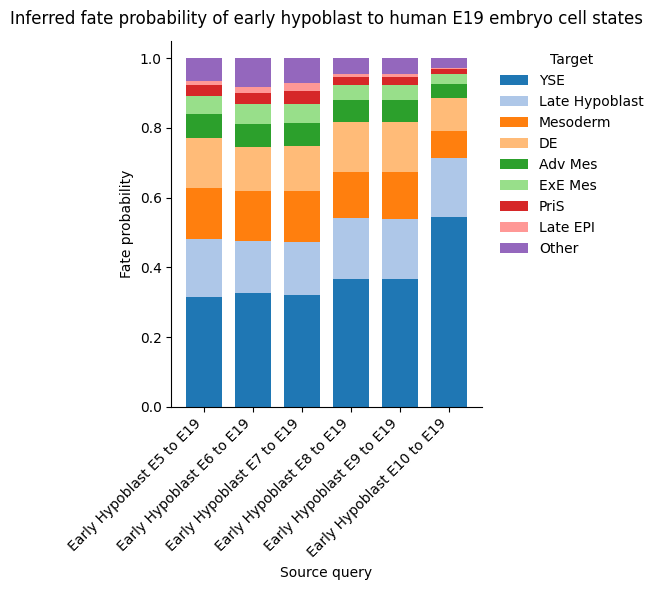

In [35]:
stack_df = plot_wot_fate_stacked_barplot(
    fate_df=fate_df,
    top_n=8,
    drop_targets=["Early_Hypoblast"],
    label_display_map=wot_label_display_map,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(6, 6),
    save_path=fig_dir / "wot_Early_Hypoblast_E5_E10_to_E19_stacked_barplot.pdf",
)

In [40]:
import numpy as np
import matplotlib.pyplot as plt


def clean_wot_source_label(x):
    """
    Convert row names like:
    'Early_Hypoblast_E5_to_E19' or 'Early Hypoblast E5 to E19'
    to:
    'E5 to E19'
    """
    x = str(x).replace("_", " ")

    x = x.replace("Early Hypoblast ", "")
    x = x.replace("early hypoblast ", "")
    x = x.replace("Early Hypoblast", "")
    x = x.replace("early hypoblast", "")

    x = x.strip()
    return x


def plot_wot_fate_stacked_barplot_refined(
    fate_df,
    top_n=8,
    drop_targets=None,
    label_display_map=None,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(5.5, 4.5),
    stack_order=None,
    color_map=None,
    save_path=None,
    dpi=300,
):
    """
    Refined stacked barplot for WOT fate probabilities.

    Parameters
    ----------
    fate_df:
        rows = source queries
        columns = target cell states
        values = fate probability

    top_n:
        Number of top target cell states to show before grouping others as "Other".

    drop_targets:
        Targets to remove before plotting, e.g. ["Early_Hypoblast"].

    stack_order:
        First item is plotted at bottom, last item is plotted at top.
        Put "YSE" last if you want blue YSE on top.

    color_map:
        Dict mapping target names to colors.

    save_path:
        Path to save figure. If None, figure is not saved.
    """

    plot_df = fate_df.copy()

    if drop_targets is not None:
        plot_df = plot_df.drop(columns=drop_targets, errors="ignore")

    # Select top targets by maximum probability across rows
    top_targets = (
        plot_df.max(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    other_targets = [x for x in plot_df.columns if x not in top_targets]

    stack_df = plot_df[top_targets].copy()

    if len(other_targets) > 0:
        stack_df["Other"] = plot_df[other_targets].sum(axis=1)

    # Default stack order: first = bottom, last = top
    if stack_order is None:
        stack_order = [
            "Other",
            "Late_EPI",
            "PriS",
            "ExE_Mes",
            "AdvMes",
            "DE",
            "Mesoderm",
            "Late_Hypoblast",
            "YSE",
        ]

    stack_order = [x for x in stack_order if x in stack_df.columns]
    remaining = [x for x in stack_df.columns if x not in stack_order]
    stack_df = stack_df[stack_order + remaining]

    # Default colors
    if color_map is None:
        color_map = {
            "YSE": "#1f77b4",
            "Late_Hypoblast": "#aec7e8",
            "Mesoderm": "#ff7f0e",
            "DE": "#ffbb78",
            "AdvMes": "#2ca02c",
            "ExE_Mes": "#98df8a",
            "PriS": "#d62728",
            "Late_EPI": "#ff9896",
            "Other": "#9467bd",
        }

    # Display labels
    display_cols = [
        label_display_map.get(x, x).replace("_", " ")
        if label_display_map is not None
        else x.replace("_", " ")
        for x in stack_df.columns
    ]

    display_rows = [clean_wot_source_label(x) for x in stack_df.index]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(stack_df.shape[0])
    bottom = np.zeros(stack_df.shape[0])

    for col, display_col in zip(stack_df.columns, display_cols):
        ax.bar(
            x,
            stack_df[col].values,
            bottom=bottom,
            label=display_col,
            color=color_map.get(col, "#BDBDBD"),
            width=0.75,
        )
        bottom += stack_df[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(display_rows, rotation=45, ha="right")

    ax.set_ylabel("Early hypoblast fate probability")
    ax.set_xlabel("Source stage")

    if title is not None:
        ax.set_title(title, pad=12)

    ax.set_ylim(0, 1.05)

    # Reverse legend so top stacked category appears first
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        title="Target",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return stack_df

Saved to /mnt/yiming/nfs_share/projects/hypoblast/results/figures/504_wot_lanner_full_plot/wot_Early_Hypoblast_E5_E10_to_E19_stacked_barplot_refined.pdf


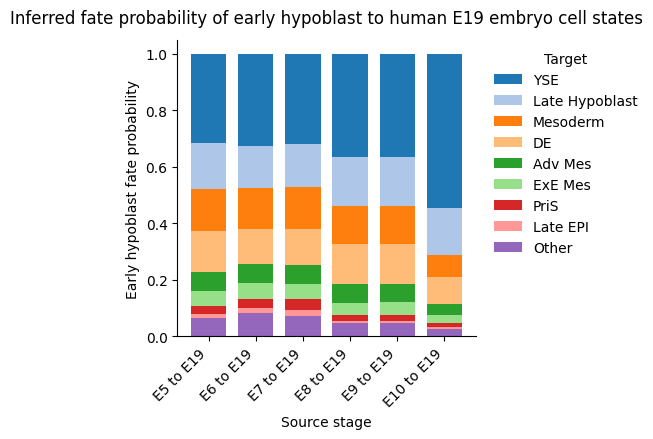

In [41]:
stack_df = plot_wot_fate_stacked_barplot_refined(
    fate_df=fate_df,
    top_n=8,
    drop_targets=["Early_Hypoblast"],
    label_display_map=wot_label_display_map,
    title="Inferred fate probability of early hypoblast to human E19 embryo cell states",
    figsize=(5.5, 4.5),
    save_path=fig_dir / "wot_Early_Hypoblast_E5_E10_to_E19_stacked_barplot_refined.pdf",
)

Saved to:
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/505_lanner_wot_plot/wot_Early_Hypoblast_E10_to_E19_fate_probability_barplot.pdf
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/505_lanner_wot_plot/wot_Early_Hypoblast_E10_to_E19_fate_probability_barplot.png


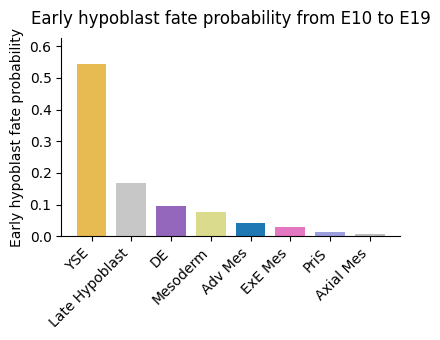

YSE               0.544888
Late_Hypoblast    0.167756
DE                0.094161
Mesoderm          0.077754
AdvMes            0.041386
ExE_Mes           0.028254
PriS              0.013400
Axial Mes         0.006066
Name: Early_Hypoblast_E10_to_E19, dtype: float64

In [ ]:
label_display_map = {
    "YSE": "YSE",
    "Late_Hypoblast": "Late Hypoblast",
    "Mesoderm": "Mesoderm",
    "DE": "DE",
    "AdvMes": "Adv Mes",
    "ExE_Mes": "ExE Mes",
    "PriS": "PriS",
    "Late_EPI": "Late EPI",
    "Other": "Other",
}

bar_s_E10_E19 = plot_wot_fate_barplot_single_source(
    fate_df,
    source_query="E10",
    target_stage="E19",
    top_n=8,
    drop_targets=None,
    label_display_map=label_display_map,
    title="Early hypoblast fate probability from E10 to E19",
    figsize=(4.2, 3.5),
    save_path=fig_dir / "wot_Early_Hypoblast_E10_to_E19_fate_probability_barplot",
    dpi=600,
)

bar_s_E10_E19